# Prediksi Kelulusan Mahasiswa Tepat Waktu
**Metodologi:** CRISP-DM

**Nama:** Selviramadani [23041450083]

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pickle

# 1.  Business Understanding 

Masalah: Penumpukan mahasiswa dan risiko penurunan kualitas (akreditasi/DO).

Solusi: Prediksi berbasis data (Machine Learning).

Faktor: Menggabungkan kriteria internal (IPK/SKS) dan eksternal (Status Kerja).

Output: Alat bantu pimpinan untuk deteksi dini (Early Warning).

# 2. Data Understanding
2.1 Identifikasi Struktur Dataset Dataset yang digunakan dalam penelitian ini terdiri dari 500 baris data mahasiswa dengan 10 kolom awal. Data mencakup informasi identitas, riwayat akademik, progres tugas akhir, hingga faktor eksternal (status kerja). Tipe data bervariasi antara integer, float, dan object (teks).2.2 Identifikasi Fitur (X) dan Target (y) Data dikelompokkan ke dalam dua kategori utama untuk proses pemodelan:Target (Label - y): Kolom Tepat_Waktu yang berisi label kategorikal "Ya" (Lulus $\le$ 4 tahun) dan "Tidak" (Lulus $> 4$ tahun).Fitur (Kriteria - X): * Akademik: Tahun_Masuk, IPK, IPS_Terakhir, MK_Gagal, SKS_Lulus.Progres Tugas Akhir: Status_Skripsi (Skala 0-4) dan Jml_Bimbingan.Eksternal: Status_Kerja.2.3 Analisis Distribusi Data & Rule-Based System Berdasarkan analisis awal, distribusi target cukup seimbang antara mahasiswa yang lulus tepat waktu dan tidak. Pengujian awal menggunakan Rule-Based System (berdasarkan kriteria IPK $\ge$ 3.0, MK Gagal $\le$ 2, dan Bimbingan $> 10$) menunjukkan adanya kesesuaian mayoritas dengan label asli. Namun, terdapat anomali di mana mahasiswa dengan performa akademik baik tetap terlambat lulus, yang mengindikasikan adanya pengaruh dari faktor eksternal seperti pekerjaan atau keaktifan organisasi yang perlu dipelajari lebih lanjut oleh model Machine Learning.

In [9]:
# Memuat dataset dari folder 'data'
df = pd.read_csv('../data/dataset_kelulusan_raw.csv')

# Menampilkan konfirmasi
print(f"Berhasil memuat {df.shape[0]} data mahasiswa.")
df.head()

Berhasil memuat 500 data mahasiswa.


,NIM,Tahun_Masuk,IPK,IPS_Terakhir,MK_Gagal,SKS_Lulus,Status_Skripsi,Jml_Bimbingan,Status_Kerja,Tepat_Waktu
0,120001,2022,2.52,2.40,5,90,0,9,Tidak,Tidak
1,120002,2020,3.90,3.79,1,140,3,14,Tidak,Ya
2,120003,2022,3.25,3.19,0,132,3,17,Tidak,Ya
3,120004,2022,3.31,3.27,2,133,3,17,Tidak,Ya
4,120005,2020,3.53,3.71,0,143,4,12,Tidak,Ya


In [10]:
# Menampilkan informasi struktur data
print(f"Dataset berhasil dimuat dengan total {df.shape[0]} baris dan {df.shape[1]} kolom.")
df.head()
print("Struktur Dataset:", df.shape)
print("\nJumlah Mahasiswa Tepat Waktu (Ya/Tidak):")
print(df['Tepat_Waktu'].value_counts())


Dataset berhasil dimuat dengan total 500 baris dan 10 kolom.
Struktur Dataset: (500, 10)

Jumlah Mahasiswa Tepat Waktu (Ya/Tidak):
Tepat_Waktu
Tidak    267
Ya       233
Name: count, dtype: int64


data preparation


In [11]:
# 1. DATA CLEANING
# Menghapus data duplikat jika ada
df = df.drop_duplicates()

# Mengecek missing values
print("Jumlah Missing Values:\n", df.isnull().sum())
# Jika ada, kita hapus (karena dataset generator biasanya bersih, ini langkah preventif)
df = df.dropna()

# 2. FEATURE SELECTION (Mencegah Data Leakage)
# Kita hapus NIM (Identitas unik) karena tidak memiliki pola akademik.
# Kita pastikan tidak ada kolom 'Tanggal Lulus' atau sejenisnya yang membocorkan jawaban ke AI.
df_selected = df.drop(columns=['NIM'])

# 3. FEATURE ENGINEERING (Membuat Fitur Baru)
# A. Progress SKS: Seberapa dekat dengan syarat lulus 144 SKS
df_selected['Progress_SKS'] = df_selected['SKS_Lulus'] / 144

# B. Tren IP: Membandingkan IPS Terakhir dengan IPK (1 jika naik/stabil, 0 jika turun)
df_selected['Trend_IP'] = (df_selected['IPS_Terakhir'] >= df_selected['IPK']).astype(int)

# C. Rata IP: Gabungan performa kumulatif dan semester terakhir
df_selected['Rata_IP'] = (df_selected['IPK'] + df_selected['IPS_Terakhir']) / 2

# 4. DATA TRANSFORMATION (Encoding)
# Mengubah data kategorikal teks menjadi numerik agar bisa diproses algoritma
# Status_Kerja: Tidak -> 0, Ya -> 1
# Tepat_Waktu: Tidak -> 0, Ya -> 1
df_selected['Status_Kerja'] = df_selected['Status_Kerja'].map({'Tidak': 0, 'Ya': 1})
df_selected['Tepat_Waktu'] = df_selected['Tepat_Waktu'].map({'Tidak': 0, 'Ya': 1})

print("Data Preparation Selesai!")
df_selected.head()

Jumlah Missing Values:
 NIM               0
Tahun_Masuk       0
IPK               0
IPS_Terakhir      0
MK_Gagal          0
SKS_Lulus         0
Status_Skripsi    0
Jml_Bimbingan     0
Status_Kerja      0
Tepat_Waktu       0
dtype: int64
Data Preparation Selesai!


,Tahun_Masuk,IPK,IPS_Terakhir,MK_Gagal,SKS_Lulus,Status_Skripsi,Jml_Bimbingan,Status_Kerja,Tepat_Waktu,Progress_SKS,Trend_IP,Rata_IP
0,2022,2.52,2.40,5,90,0,9,0,0,0.625000,0,2.460
1,2020,3.90,3.79,1,140,3,14,0,1,0.972222,0,3.845
2,2022,3.25,3.19,0,132,3,17,0,1,0.916667,0,3.220
3,2022,3.31,3.27,2,133,3,17,0,1,0.923611,0,3.290
4,2020,3.53,3.71,0,143,4,12,0,1,0.993056,1,3.620


modelling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. PENENTUAN FITUR & TARGET
# =========================================================
# X adalah fitur input, y adalah target yang diprediksi
X = df_selected.drop(columns=['Tepat_Waktu'])
y = df_selected['Tepat_Waktu']

# =========================================================
# 2. SPLIT DATA (Standard Industri 80:20)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================================================
# 3. PENYIMPANAN DATA TRAINING & TESTING (Audit Trail)
# =========================================================
# Membuat salinan untuk disimpan ke CSV
df_train = X_train.copy()
df_train['Tepat_Waktu'] = y_train

df_test = X_test.copy()
df_test['Tepat_Waktu'] = y_test

# Simpan ke folder data
df_train.to_csv('../data/train.csv', index=False)
df_test.to_csv('../data/test.csv', index=False)

# =========================================================
# 4. TRAINING MODEL (Building the AI)
# =========================================================
# Menggunakan Random Forest Classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# =========================================================
# 5. PENYIMPANAN MODEL (.pkl untuk Streamlit)
# =========================================================
if not os.path.exists('../models'):
    os.makedirs('../models')

joblib.dump(model_rf, '../models/model_prediksi_kelulusan.pkl')

print("✓ Tahap Modeling Selesai & Model telah diekspor.")

✓ Tahap Modeling Selesai & Model telah diekspor.


Hasil Akurasi Model: 92.00%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        50
           1       0.89      0.96      0.92        50

    accuracy                           0.92       100
   macro avg       0.92      0.92      0.92       100
weighted avg       0.92      0.92      0.92       100



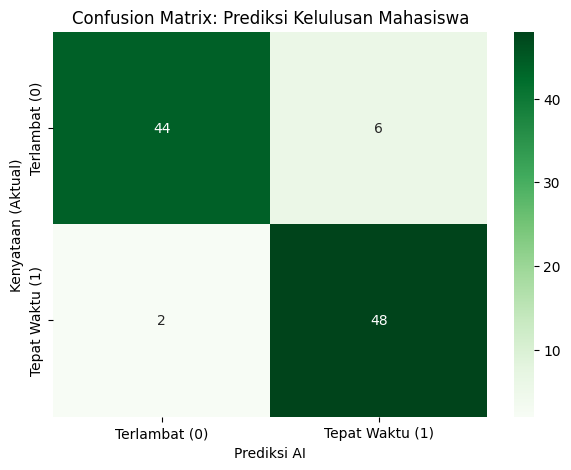

: 

In [ ]:
# =========================================================
# 6. PREDIKSI & EVALUASI
# =========================================================
# Melakukan prediksi pada data testing yang belum pernah dilihat model
y_pred = model_rf.predict(X_test)

# Menghitung akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Hasil Akurasi Model: {akurasi * 100:.2f}%")

# Laporan detail Precision, Recall, dan F1-Score
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Terlambat (0)', 'Tepat Waktu (1)'],
            yticklabels=['Terlambat (0)', 'Tepat Waktu (1)'])
plt.title('Confusion Matrix: Prediksi Kelulusan Mahasiswa')
plt.xlabel('Prediksi AI')
plt.ylabel('Kenyataan (Aktual)')
plt.show()